# EDA: UCI Cleveland heart disease
Reads `patients_raw` from Postgres via `src.data`.

In [1]:
import sys; sys.path.insert(0, '..')
import matplotlib.pyplot as plt, seaborn as sns
import pandas as pd
from src.data import read_raw, validate, binarise, dedupe
from src.config import NUMERIC
raw = read_raw(); validate(raw)
df, n_dup = dedupe(binarise(raw)); print(raw.shape, 'duplicates removed:', n_dup)

(303, 14) duplicates removed: 0


## Missing values

In [2]:
pd.DataFrame({'missing': raw.isna().sum(), 'pct': (raw.isna().mean()*100).round(2)})[lambda t: t.missing > 0]

,missing,pct
ca,4,1.32
thal,2,0.66


Only `ca` (4) and `thal` (2). No `chol = 0` / `trestbps = 0` (checked below).

In [3]:
print('chol==0:', (raw.chol == 0).sum(), '| trestbps==0:', (raw.trestbps == 0).sum())

chol==0: 0 | trestbps==0: 0


## Class balance

target
0    164
1    139
Name: count, dtype: int64 0.459


<Axes: title={'center': 'target (1 = disease)'}, xlabel='target'>

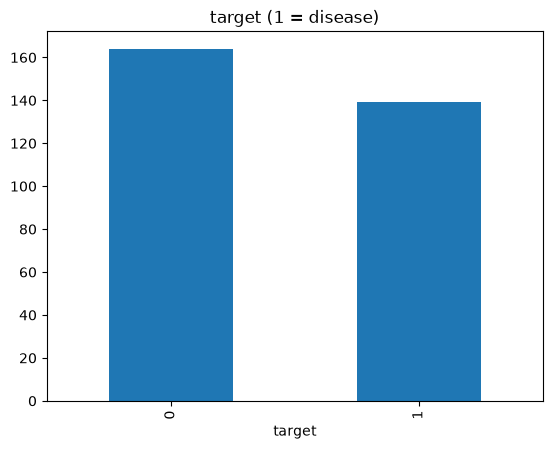

In [4]:
print(df.target.value_counts(), df.target.mean().round(3))
df.target.value_counts().plot.bar(title='target (1 = disease)')

## Numeric features by target

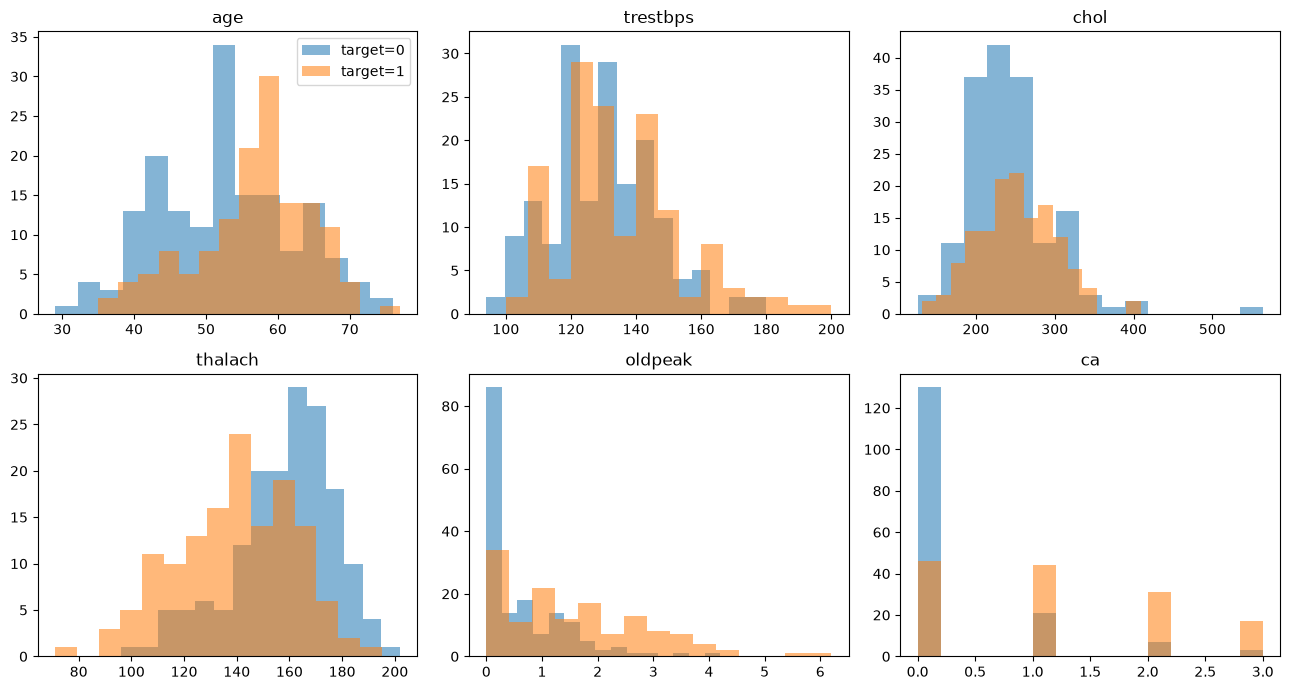

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, c in zip(axes.ravel(), NUMERIC):
    for t, g in df.groupby('target'):
        ax.hist(g[c].dropna(), bins=15, alpha=.55, label=f'target={t}')
    ax.set_title(c)
axes[0,0].legend(); plt.tight_layout()

## Label direction check
Disease rows must have higher `ca` and `oldpeak` (the Kaggle copy is inverted).

In [6]:
df.groupby('target')[['ca', 'oldpeak', 'thalach', 'exang']].mean()

,ca,oldpeak,thalach,exang
target,,,,
0,0.273292,0.586585,158.378049,0.140244
1,1.137681,1.574101,139.258993,0.546763


## Correlation

<Axes: >

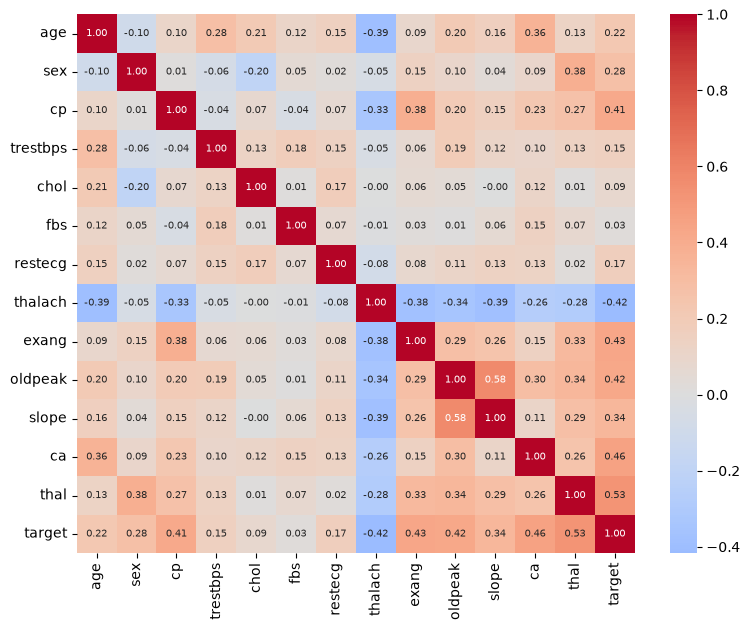

In [7]:
plt.figure(figsize=(9, 7)); sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size': 7})

## Near-duplicate patients (flagged, not fixed)
Rows identical on all but one feature.

In [8]:
import numpy as np
X = df.drop(columns='target').fillna(-1).to_numpy()
diff = (X[:, None, :] != X[None, :, :]).sum(-1)
print('pairs differing in exactly 1 feature:', int(((diff == 1).sum()) / 2))

pairs differing in exactly 1 feature: 0
